In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt
import xarray as xr
import torch
import torch.nn as nn
from tqdm import trange
from torchmetrics.regression import R2Score
from torch.utils.data import Dataset, DataLoader
import os
from pathlib import Path
from datetime import datetime
from data_utils import load_DYAMOND_data, load_grid
from train_ODE_and_parametrization import load_NNODE_checkpoint
from data_utils import CoordDataset
from torch.utils.data import DataLoader
import warnings
import pickle
import pandas as pd
from parametrizations import BaseParametrization
import sympy as sp
from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Evaluate Xi coefficients

In [ ]:
model = load_NNODE_checkpoint('networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260508202548_linear_4d_corrected_00_timesteps.pkl')
sympy_eq = model.ODE.sympy()
Xi = {'LHS': [], 'b': [], 'z1': [], 'z2': [], 'z3': [], 'z4': [], 'qv2m': [], 'Prw': [], 'T2m': [], 'Ts': [], 'Fs': [], 'Fl': []}
for i, target in enumerate(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']):
    Xi['LHS'].append(target)
    Xi['b'].append(float(sympy_eq[i].as_coeff_add()[1][0]))
    for sym in list(sympy_eq[i].free_symbols):
        Xi[str(sym)].append(float(sympy_eq[i].coeff(sym)))
Xi = pd.DataFrame(Xi)
numeric_cols = Xi.select_dtypes(include='number').columns
Xi_z = Xi[['z1', 'z2', 'z3', 'z4']].values
half_life = np.abs(np.log(2) / np.real(np.linalg.eigvals(Xi_z)) * 15 / 60)
period = np.absolute(2 *np.pi / np.imag(np.linalg.eigvals(Xi_z)) * 15 / 60)
period[np.isinf(period)] = None
Xi['half-life'] = half_life
Xi['period'] = period


/tmp/ipykernel_2517853/3362699977.py:13: RuntimeWarning: divide by zero encountered in divide
  period = np.absolute(2 *np.pi / np.imag(np.linalg.eigvals(Xi_z)) * 15 / 60)


In [6]:
#L96_Xi = np.load('/work/bd1179/b309297/L96/ODEs/m=0.001_tau=0.001/dim=8_decoder=True_deg=1_lambda=0.0_finitedifference.npy')
L96_Xi = np.load('/work/bd1179/b309297/L96/ODEs/m=0.001_tau=0.001/dim=6_decoder=True_deg=1_lambda=0.0_finitedifference.npy')
L96_Xi = pd.DataFrame(L96_Xi, columns=['b', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'X'])
L96_Xi['LHS'] = [f'z{i}_dot' for i in range(1, 7)]
L96_Xi_z = L96_Xi[['z1', 'z2', 'z3', 'z4', 'z5', 'z6']].values
L96_Xi['half-life'] = np.abs(np.log(2) / np.real(np.linalg.eigvals(L96_Xi_z))) 
period =  np.abs(2 *np.pi / np.imag(np.linalg.eigvals(L96_Xi_z))) 
period[np.isinf(period)] = None
L96_Xi['period'] = period
print(np.linalg.eigvals(L96_Xi_z))

[-1.22484886+10.71404609j -1.22484886-10.71404609j
 -3.26300128 +7.35089443j -3.26300128 -7.35089443j
 -3.05218478 +2.80968077j -3.05218478 -2.80968077j]


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_coefficient_matrix(Xi, fig=None, ax=None):
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif"
    })
    FS = 16

    # --- Labels ---
    latex_map = {
        'LHS': r'$\dot{z}_l$',
        'b': r'$b$',
        'z1': r'$z_1$',
        'z2': r'$z_2$',
        'z3': r'$z_3$',
        'z4': r'$z_4$',
        'z5': r'$z_5$',
        'z6': r'$z_6$',
        'z7': r'$z_7$',
        'z8': r'$z_8$',
        'qv2m': r'$q_{2m}$',
        'Prw': r'$PW$',
        'T2m': r'$T_{2m}$',
        'Ts': r'$T_{sfc}$',
        'Fs': r'$H$',
        'Fl': r'$LE$',
        'X': r'$X$',
        r'$Re(\lambda_i)$': r'$\mathrm{Re}(\lambda_i)$',
        r'$Im(\lambda_i)$': r'$\mathrm{Im}(\lambda_i)$',
        'half-life': r'$\frac{-\ln(2)}{\mathrm{Re}(\lambda_i)}$',
        'period': r'$\frac{2\pi}{|\mathrm{Im}(\lambda_i)|}$'
    }

    eig_real = 'half-life'
    eig_imag = 'period'

    # --- Detect complex eigenvalue column and split ---
    if eig_real not in Xi.columns and eig_imag not in Xi.columns:
        eig_candidates = [c for c in Xi.columns if 'lambda' in c]
        if len(eig_candidates) == 0:
            raise ValueError("No eigenvalue column found.")
        eig_col = eig_candidates[0]

        Xi = Xi.copy()
        # Extract real and imaginary parts
        Xi[eig_real] = np.real(Xi[eig_col])
        Xi[eig_imag] = np.imag(Xi[eig_col])

    # --- Arrange columns ---
    coef_cols = [c for c in Xi.columns if c not in ['LHS', eig_real, eig_imag]]
    cols = coef_cols + [eig_real, eig_imag]

    Xi_numeric = Xi[cols].copy()
    data = Xi_numeric.values

    eig_start = cols.index(eig_real)
    coef_data = data[:, :eig_start]

    # --- Detect z-column boundary ---
    z_start = None
    z_end = 0
    for i, col in enumerate(cols):
        if col.startswith('z') and len(col) > 1 and col[1:].isdigit():
            if z_start is None:
                z_start = i
            z_end = i + 1
        elif z_start is not None and z_end > 0:
            break  # Stop after consecutive z-columns end

    # --- Symmetric color scaling (ONLY coefficients) ---
    vmax = np.abs(coef_data).max()
    vmin = -vmax

    # --- Figure ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    # --- Heatmap (coefficients only) ---
    im = ax.imshow(coef_data, cmap='coolwarm', vmin=vmin, vmax=vmax)

    ax.set_xlim(-0.5, len(cols) - 0.5)
    ax.set_ylim(len(Xi) - 0.5, -0.5)

    # --- White background for eigenvalue columns ---
    for i in range(data.shape[0]):
        for j in range(eig_start, eig_start + 2):
            ax.add_patch(
                plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                              facecolor='white', edgecolor='none')
            )

    # --- Ticks ---
    ax.set_xticks(np.arange(len(cols)))
    ax.set_yticks(np.arange(len(Xi)))

    ax.set_xticklabels(
        [latex_map.get(c, c) for c in cols],
        rotation=45, ha='right', fontsize=FS + 2
    )
    ax.set_yticklabels(
        [rf'$\dot{{z}}_{i+1}$' for i in range(len(Xi))],
        fontsize=FS + 2
    )

    # --- Annotate all values ---
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]

            if j >= eig_start:
                if j == eig_start:  # Real part: half-life
                    text = f"{val:.2f}"
                else:  # Imaginary part → period
                    # Check if imaginary part is effectively zero (real eigenvalue)
                    if abs(val) < 1e-10 or np.isnan(val) or np.isinf(val):
                        text = "—"#"-"
                    else:
                        period = val
                        text = f"{period:.2f}"
            else:
                # Coefficient values
                text = f"{val:.2f}"

            ax.text(j, i, text,
                    ha="center", va="center",
                    color="black", fontsize=FS)

    # --- Separators around z-coefficients ---
    if z_start is not None and z_end > 0:
        # Left of first z-variable
        x_z_left = z_start - 0.5
        ax.axvline(x_z_left, color='black', linewidth=1.5, linestyle='-')
        
        # Right of last z-variable (only if there are non-z coefficients after)
        if z_end < eig_start:
            x_z_right = z_end - 0.5
            ax.axvline(x_z_right, color='black', linewidth=1.5, linestyle='-')

    # --- Double separator before eigenvalues ---
    x_left = eig_start - 0.5
    ax.axvline(x_left - 0.03, color='black', linewidth=1.5)
    ax.axvline(x_left + 0.03, color='black', linewidth=1.5)

    # --- Right border ---
    x_right = eig_start + 1.5
    ax.axvline(x_right, color='black', linewidth=1.5)

    # --- Colorbar ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.15)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'Coefficient value', fontsize=FS)
    cbar.ax.tick_params(labelsize=FS)

    ax.set_title("")
    # plt.tight_layout()

    return fig, ax

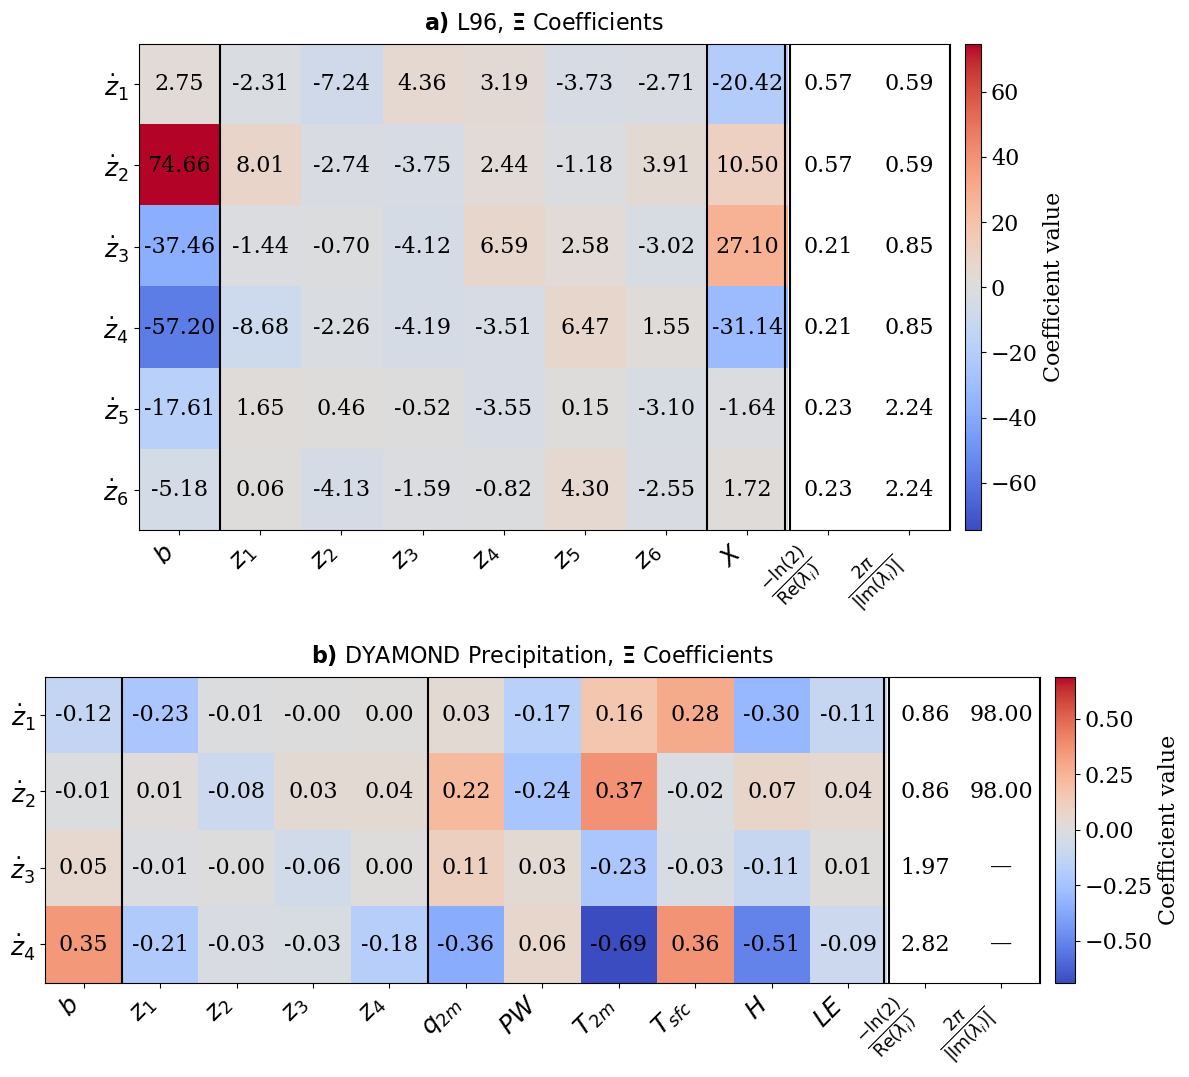

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Get actual matrix dimensions ---
n_rows_L96 = L96_Xi.shape[0]  # Number of rows in L96_Xi
n_rows_DYAMOND = Xi.shape[0]   # Number of rows in Xi

# --- Use height ratios based on actual data size ---
height_ratios = [n_rows_L96, n_rows_DYAMOND]

# --- Create figure with constrained layout for minimal whitespace ---
# fig = plt.figure(figsize=(12, 10), constrained_layout=False)  # Let GridSpec handle layout
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 11), gridspec_kw={"height_ratios": [3, 2.5]})

# --- Create subplots (stacked vertically) ---
# ax0 = fig.add_subplot(gs[0, 0])  # Top: L96
# ax1 = fig.add_subplot(gs[1, 0])  # Bottom: DYAMOND

# --- Plot matrices ---
plot_coefficient_matrix(L96_Xi, fig, ax0)
plot_coefficient_matrix(Xi, fig, ax1)

# --- Titles ---
ax0.set_title(r'$\mathbf{a)}$ L96, $\mathbf{\Xi}$ Coefficients', fontsize=16, pad=10)
ax1.set_title(r'$\mathbf{b)}$ DYAMOND Precipitation, $\mathbf{\Xi}$ Coefficients', fontsize=16, pad=10)

# --- Remove extra whitespace and ensure tight layout ---
# Use constrained_layout to avoid padding issues
plt.tight_layout()
plt.savefig('plots_paper/Xi_coefficients_vertical_compact.png', dpi=200, bbox_inches='tight')

In [8]:
with open('SINDy_ODEs/equations/model_20260507185408_linear_ODE_4d_past_timesteps=20.pkl', 'rb') as f:
    sympy_eq = pickle.load(f)
Xi_offline = {'LHS': [], 'b': [], 'z1': [], 'z2': [], 'z3': [], 'z4': [], 'qv2m': [], 'Prw': [], 'T2m': [], 'Ts': [], 'Fs': [], 'Fl': []}
for i, target in enumerate(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']):
    Xi_offline['LHS'].append(target)
    Xi_offline['b'].append(float(sympy_eq[i].as_coeff_add()[1][0]))
    for sym in list(sympy_eq[i].free_symbols):
        Xi_offline[str(sym)].append(float(sympy_eq[i].coeff(sym)))
Xi_offline = pd.DataFrame(Xi_offline)
numeric_cols = Xi_offline.select_dtypes(include='number').columns
Xi_z = Xi_offline[['z1', 'z2', 'z3', 'z4']].values
half_life = np.abs(np.log(2) / np.real(np.linalg.eigvals(Xi_z)) * 15 / 60)
period = np.abs(2 *np.pi / np.imag(np.linalg.eigvals(Xi_z)) * 15 / 60)
period[np.isinf(period)] = None
Xi_offline['half-life'] = half_life
Xi_offline['period'] = period

/tmp/ipykernel_2517853/541520268.py:13: RuntimeWarning: divide by zero encountered in divide
  period = np.abs(2 *np.pi / np.imag(np.linalg.eigvals(Xi_z)) * 15 / 60)


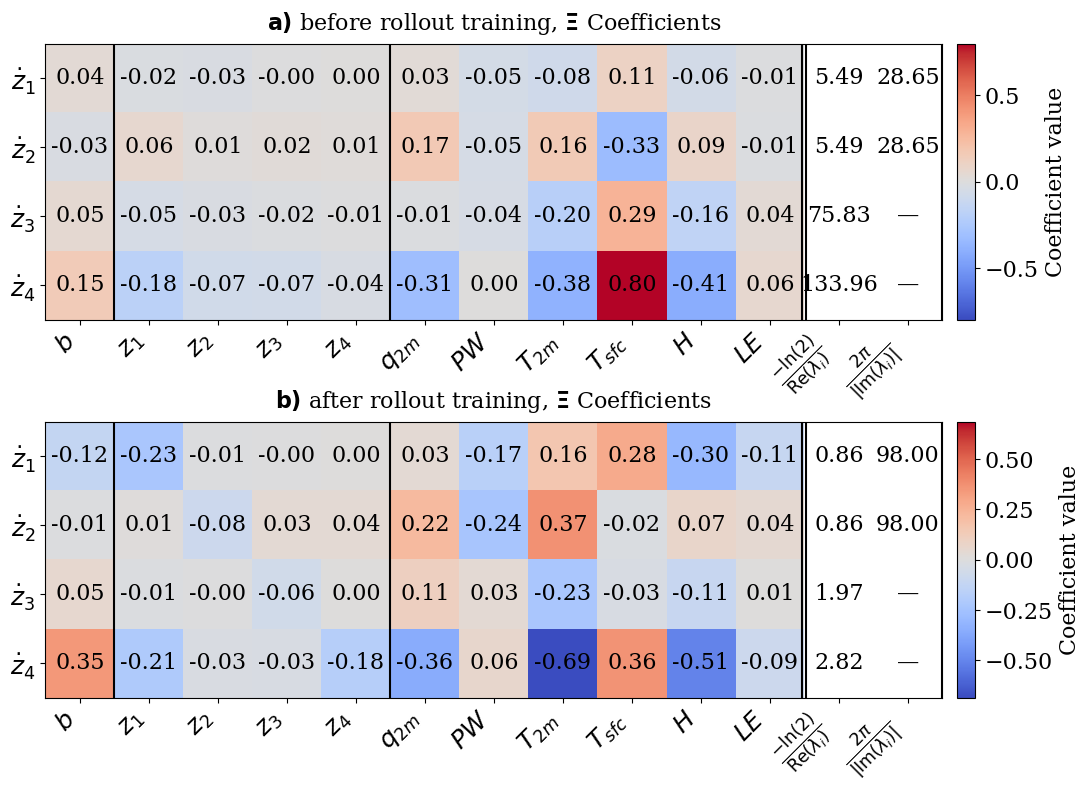

In [9]:
# --- Create figure with constrained layout for minimal whitespace ---
# fig = plt.figure(figsize=(12, 10), constrained_layout=False)  # Let GridSpec handle layout
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 9))

# --- Create subplots (stacked vertically) ---
# ax0 = fig.add_subplot(gs[0, 0])  # Top: L96
# ax1 = fig.add_subplot(gs[1, 0])  # Bottom: DYAMOND

# --- Plot matrices ---
plot_coefficient_matrix(Xi_offline, fig, ax0)
plot_coefficient_matrix(Xi, fig, ax1)

# --- Titles ---
ax0.set_title(r'$\mathbf{a)}$ before rollout training, $\mathbf{\Xi}$ Coefficients', fontsize=16, pad=10)
ax1.set_title(r'$\mathbf{b)}$ after rollout training, $\mathbf{\Xi}$ Coefficients', fontsize=16, pad=10)

plt.savefig('plots_paper/Xi_coefficients_offline_vs_online.png', dpi=200, bbox_inches='tight')

### Train ODE

In [ ]:
# Load Z data
#XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260417112208_global_ocean_land_rp=False_Ztest_ConvNN+AE+D_tp=20_wd=None.npy')
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260417112208_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=None.npy')
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_test = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Ztest_ConvNN+AE+D_tp=20_wd=0.0.npy')

In [ ]:
sep = 10
all_features = np.array(['coord', 'qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'l', 'z1', 'z2', 'z3', 'z4'])
x_inds = [1, 2, 3, 4, 5, 6]
first_z_ind = -4
feature_names = list(all_features[first_z_ind:]) + list(all_features[x_inds]) 
x_train= list(XZ_train[::sep, :, x_inds])
z_train= list(XZ_train[::sep, :, first_z_ind:])
x_val= list(XZ_val[::sep, :, x_inds])
z_val= list(XZ_val[::sep, :, first_z_ind:])

In [ ]:
# Learn ODE without other Z_k variables
opt = ps.STLSQ(threshold=0.0)
lib = ps.PolynomialLibrary(degree=1)
model = ps.SINDy(feature_library=lib, 
                 differentiation_method=ps.FiniteDifference(),
                 #differentiation_method=ps.SmoothedFiniteDifference(smoother_kws={'window_length': 10}), 
                 optimizer=opt)

model.fit(x=z_train, u=x_train, t=1, feature_names=feature_names)
model.print()  
model.score(x=z_val, u=x_val, t=1, multioutput='raw_values')

(z1)' = 0.036 1 + -0.021 z1 + -0.028 z2 + -0.002 z3 + 0.002 z4 + 0.030 qv2m + -0.050 Prw + -0.080 T2m + 0.106 Ts + -0.062 Fs + -0.009 Fl
(z2)' = -0.026 1 + 0.059 z1 + 0.008 z2 + 0.021 z3 + 0.015 z4 + 0.165 qv2m + -0.045 Prw + 0.162 T2m + -0.329 Ts + 0.087 Fs + -0.013 Fl
(z3)' = 0.050 1 + -0.048 z1 + -0.029 z2 + -0.018 z3 + -0.006 z4 + -0.014 qv2m + -0.038 Prw + -0.197 T2m + 0.286 Ts + -0.159 Fs + 0.035 Fl
(z4)' = 0.151 1 + -0.183 z1 + -0.069 z2 + -0.067 z3 + -0.036 z4 + -0.315 qv2m + -0.382 T2m + 0.796 Ts + -0.407 Fs + 0.058 Fl


array([0.78064166, 0.28824473, 0.52307145, 0.40662081])

In [ ]:
def save_sindy_equations(model, file_name):
    # Define symbols
    symbols = sp.symbols('qv2m Prw T2m Ts Fs Fl z1 z2 z3 z4')

    # Map names → symbols
    local_dict = {str(s): s for s in symbols}

    # Enable implicit multiplication
    transformations = standard_transformations + (
        implicit_multiplication_application,
    )

    equations = model.equations(precision=16)

    sympy_equations = [
        parse_expr(eq, local_dict=local_dict,
                transformations=transformations)
        for eq in equations
    ]

    with open(f'SINDy_ODEs/equations/{file_name}.pkl', 'wb') as f:
        pickle.dump(sympy_equations, f)
        
save_sindy_equations(model, 'model_20260507185408_linear_ODE_4d_past_timesteps=20')

In [ ]:
np.real(np.linalg.eigvals(model.coefficients()[:, 1: 4 + 1]))  # Compute eigenvalues of coefficient matrix corresponding to z variables

array([-0.06117239, -0.06117239, -0.00370833, -0.00932859])

### Nonlinear ODE coefficients

In [195]:
import sympy as sp
import pickle
from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application
)

# Define symbols
symbols = sp.symbols('qv2m Prw T2m Ts Fs Fl z1 z2 z3 z4')

# Map names → symbols
local_dict = {str(s): s for s in symbols}

# Enable implicit multiplication
transformations = standard_transformations + (
    implicit_multiplication_application,
)

equations = model.equations(precision=16)

sympy_equations = [
    parse_expr(eq, local_dict=local_dict,
               transformations=transformations)
    for eq in equations
]

# with open('linear_ODE_4d_sympy_equations.pkl', 'wb') as f:
#     pickle.dump(sympy_equations, f)

In [ ]:
import sympytorch
from data_utils import CoordDataset
from torch.utils.data import DataLoader
import warnings
import pickle
from parametrizations import BaseParametrization
models_st = sympytorch.SymPyModule(expressions=sympy_equations)

In [ ]:
%load_ext autoreload
%autoreload 2
from train_ODE_and_parametrization import NN_ODE
def load_NNODE_checkpoint(path):
    checkpoint = torch.load(path, weights_only=False, map_location=device)
    model = NN_ODE(**checkpoint['model_kwargs'])
    model.ODE.load_state_dict(checkpoint['ODE_state'], )
    model.neural_net.load_state_dict(checkpoint['NN_state'])
    model.set_metadata(checkpoint['metadata'])

    return model

# path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260318180651.pkl'
path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511173500_nonlinear_4d_corrected_00_timesteps_0.pkl'
#path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511163124_nonlinear_4d_corrected_00_timesteps.pkl'
model_nonlin = load_NNODE_checkpoint(path)
path = 'nonlinear_ODE_residual_approach_4d_sympy_equations.pkl'
model_residual_nonlin = load_NNODE_checkpoint(path)

# path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260407224011_nonlinear_residual.pkl'
# model_resnonlin = load_NNODE_checkpoint(path)
path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260508202548_linear_4d_corrected_00_timesteps.pkl'
model_lin = load_NNODE_checkpoint(path)

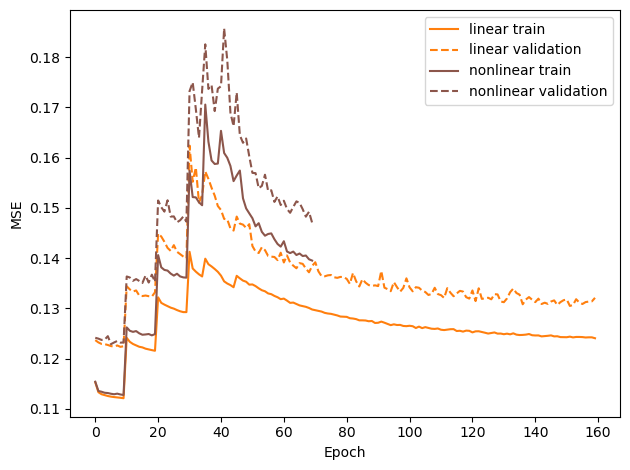

In [4]:
vlines = [0, 100, 200, 210, 220, 230, 235]
t_rollouts = [5, 10, 20, 50, 100, 200, 300]

plt.plot(model_lin.train_loss, label='linear train', color='tab:orange')
plt.plot(model_lin.val_loss, label='linear validation', color='tab:orange', linestyle='--')

# plt.plot(model_resnonlin.train_loss, label='residual nonlinear train', color='tab:orange')
# plt.plot(model_resnonlin.val_loss, label='residual nonlinear validation', color='tab:orange', linestyle='--')

plt.plot(model_nonlin.train_loss, label='nonlinear train', color='tab:brown')
plt.plot(model_nonlin.val_loss, label='nonlinear validation', color='tab:brown', linestyle='--')

#plt.vlines(vlines, ymin=.116, ymax=.15, linestyles='--', color='grey')

# Add text labels
for x, t in zip(vlines, t_rollouts):
    #plt.text(x, 0.115, rf'$t_r={{{t}}}$', ha='center', va='top', fontsize=10, rotation=45)
    pass

plt.xlabel('Epoch')
plt.ylabel('MSE')
# plt.ylim(.11, .15)
plt.legend()
plt.tight_layout()
# plt.savefig('plots_paper/NN_ODE_loss_curves.png', dpi=200, bbox_inches='tight')

In [24]:
with open('qlattice_equations/laten_dims=4_complexity=10_n_epochs=1000/nonlinear_models_selection_sympy.pkl', 'rb') as f:
    sympy_eq_nonlin = pickle.load(f)

In [ ]:
model_nonlin.ODE.sympy() # after rollout training
sympy_eq_nonlin # before rollout training

sympy.core.add.Add

In [38]:
import sympy as sp
from sympy import latex, N, symbols

def create_aligned_latex_with_mapping(equations, var_mapping, sig_figs=3):
    """Create aligned LaTeX equations with variable name mapping"""
    latex_lines = []
    
    # Create symbol mappings
    symbol_map = {}
    for old_name, new_name in var_mapping.items():
        symbol_map[symbols(old_name)] = symbols(new_name)
    
    # Format as aligned equations
    latex_lines.append("\\begin{align*}")
    for i, eq in enumerate(equations):
        # Round constants
        rounded_eq = eq.xreplace({
            c: N(c, sig_figs) for c in eq.atoms() if c.is_number
        })
        
        # Apply variable name mapping
        for old_sym, new_sym in symbol_map.items():
            rounded_eq = rounded_eq.subs(old_sym, new_sym)
        
        latex_str = latex(rounded_eq)
        # Remove "Eq(" and ")" from the beginning/end if present
        if latex_str.startswith("Eq(") and latex_str.endswith(")"):
            latex_str = latex_str[3:-1]
        latex_lines.append(f"\\dot z_{{{i+1}}} &= {latex_str} \\\\")
    latex_lines.append("\\end{align*}")
    
    return "\n".join(latex_lines)

# Variable mapping dictionary
var_mapping = {
    'Prw': 'PW', 
    'T2m': 'T_{\\text{2m}}', 
    'Ts': 'T_{sfc}', 
    'qv2m': 'q_{\\text{2m}}', 
    'Fs': 'H', 
    'Fl': 'LE'
}

# Usage for your equations:
print("Before rollout training:")
print(create_aligned_latex_with_mapping(sympy_eq_nonlin, var_mapping, sig_figs=3))

print("\nAfter rollout training:")
print(create_aligned_latex_with_mapping(model_nonlin.ODE.sympy(), var_mapping, sig_figs=3))

Before rollout training:
\begin{align*}
\dot z_{1} &= - 0.111 H - 0.0205 z_{1} - 0.321 \tanh{\left(0.58 PW + \left(0.694 - 0.127 z_{2}\right) \left(- 1.13 q_{\text{2m}} - 2.6\right) - 0.267 \right)} - 0.285 \\
\dot z_{2} &= - 4.15 \left(- 0.0184 z_{4} - 1.0 \tanh{\left(0.13 z_{1} + 0.0876 z_{2} + 0.906 \right)} + 1.01\right) e^{- 2.0 \left(1.04 - 0.0433 z_{3}\right)^{2.0} - 2.0 \left(- 0.144 H - 0.304\right)^{2.0}} + 0.0608 \\
\dot z_{3} &= 11.8 \left(- 0.000967 z_{4} + e^{- 2.0 \left(0.0544 H + 0.854\right)^{2.0} \left(- 0.00567 z_{2} - 0.648\right)^{2.0} - 2.0 \left(0.0112 z_{1} + 0.542\right)^{2.0}} - 0.314\right) e^{- 2.0 \left(0.0372 z_{3} - 0.706\right)^{2.0}} + 0.0809 \\
\dot z_{4} &= - 20.8 \left(0.384 H - 1.15\right) \left(0.00247 z_{4} + e^{- 2.0 \left(0.0182 z_{1} + 0.943\right)^{2.0} - 2.0 \left(- 0.013 z_{3} - 0.215\right)^{2.0}} - 0.0726\right) - 20.8 \left(- 0.00683 z_{4} - 0.374\right)^{2.0} + 1.06 \\
\end{align*}

After rollout training:
\begin{align*}
\dot z_{1} &= - 

### Precip Prediction

In [ ]:
# Load baseline run to get the missing forcings
onlyX_train = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Ztrain_NNbase_tp=0_wd=0.0.npy')
onlyX_val = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Zval_NNbase_tp=0_wd=0.0.npy')
onlyX_test = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Ztest_NNbase_tp=0_wd=0.0.npy')

In [ ]:
onlyX_train = onlyX_train[XZ_train[:, 0, 0].astype(int)]
onlyX_val = onlyX_val[XZ_val[:, 0, 0].astype(int)]
onlyX_test = onlyX_test[XZ_val[:, 0, 0].astype(int)]

In [ ]:
onlyX = np.concat((onlyX_train, onlyX_val, onlyX_test), axis=1)
del onlyX_train, onlyX_val, onlyX_test

In [ ]:

# Add four empty columns to the last dimension
X_emptyZ_val = np.concatenate((onlyX, np.zeros((onlyX.shape[0], onlyX.shape[1], 4))), axis=-1)
del onlyX

In [ ]:
X_emptyZ_val.shape

(81920, 2976, 14)

In [ ]:
xp_inds = [1, 2, 3, 4, 5, 6, 7, 8]
latent_dims = 4
# XP_train = torch.tensor(XZ_train[:, :, xp_inds], dtype=torch.float32, device=device)
# XP_val = torch.tensor(XZ_val[:, :, xp_inds], dtype=torch.float32, device=device)
# XP_test = torch.tensor(XZ_test[:, :, xp_inds], dtype=torch.float32, device=device)
# Z_train = torch.tensor(XZ_train[:, :, -latent_dims:], dtype=torch.float32, device=device)
# Z_val = torch.tensor(XZ_val[:, :, -latent_dims:], dtype=torch.float32, device=device)
# Z_test = torch.tensor(XZ_test[:, :, -latent_dims:], dtype=torch.float32, device=device)

# Create merged dataset of val and train, along temporal dimension
XP_emptyZ_val = torch.tensor(X_emptyZ_val[:, :, xp_inds], dtype=torch.float32, device=device)
Z_emptyZ_val = torch.tensor(X_emptyZ_val[:, :, -latent_dims:], dtype=torch.float32, device=device)
# XP_merged = torch.cat((XP_train, XP_emptyZ_val), dim=1)
# Z_merged = torch.cat((Z_train, Z_emptyZ_val), dim=1)
XP_merged = XP_emptyZ_val
Z_merged = Z_emptyZ_val
del XP_emptyZ_val, Z_emptyZ_val, X_emptyZ_val

In [13]:
print(XP_merged.shape)
print(Z_merged.shape)

torch.Size([81920, 2976, 8])
torch.Size([81920, 2976, 4])


In [14]:
t_rollout = 2975
# tmax_train = XP_train.shape[1]
# tmax_val = XP_val.shape[1]
# tmax_test = XP_test.shape[1]
tmax_merged = XP_merged.shape[1]
# t_prediction_train = np.arange(start=t_rollout, stop=tmax_train, step=t_rollout)
# t_prediction_val = np.arange(start=t_rollout, stop=tmax_val, step=t_rollout)
# t_prediction_test = np.arange(start=t_rollout, stop=tmax_test, step=t_rollout)
t_prediction_merged = np.arange(start=t_rollout, stop=tmax_merged, step=t_rollout)
coords = np.arange(XP_merged.shape[0], step=1)
#coords = np.array([123])
# XP_batch = XP_train[coords] # grab batch
# Z_batch = Z_train[coords]
# Z_batch = torch.zeros_like(Z_batch)  
# XP_batch = XP_merged[coords] # grab batch
# Z_batch = Z_merged[coords]


In [15]:
Ncoords = XP_merged.shape[0]
Ncoords // 5

16384

In [16]:
t_rollout

2975

In [17]:
Pr_lins = []
Pr_pred_lins = []
Nbatches = 5
for i in range(1, Nbatches + 1):
    print(f'Batch {i}')
    coords_subset = coords[(i-1) * Ncoords//Nbatches: i*Ncoords//Nbatches]
    XP_batch = XP_merged[coords_subset] # grab batch
    Z_batch = Z_merged[coords_subset]
    Pr_lin, Pr_pred_lin = model_lin.forward(coords_subset, XP_batch, Z_batch, t_prediction_merged, t_rollout)
    Pr_lins.append(Pr_lin.cpu().detach().numpy().reshape(t_rollout, -1).T)  # Reshape back to (N_coords, N_timesteps)
    Pr_pred_lins.append(Pr_pred_lin.cpu().detach().numpy().reshape(t_rollout, -1).T)  # Reshape back to (N_coords, N_timesteps)

Batch 1
Batch 2
Batch 3
Batch 4
Batch 5


In [18]:
Pr_lins = np.concatenate(Pr_lins, axis=0)
Pr_pred_lins = np.concatenate(Pr_pred_lins, axis=0)

In [19]:
Pr_lins.shape

(81920, 2975)

In [10]:
Pr_nonlin, Pr_pred_nonlin = model_nonlin.forward(coords, XP_batch, Z_batch, t_prediction_val, t_rollout)

In [11]:
Pr_resnonlin, Pr_pred_resnonlin = model_resnonlin.forward(coords, XP_batch, Z_batch, t_prediction_val, t_rollout)

In [20]:
t_spinup = 30
print('linear model R^2', R2Score()(torch.tensor(Pr_pred_lins[:, t_spinup:]).flatten(), torch.tensor(Pr_lins[:, t_spinup:]).flatten()).item())
# print('nonlinear model R^2', R2Score()(Pr_pred_nonlin, Pr_nonlin).item())
# print('residual nonlinear model R^2', R2Score()(Pr_pred_resnonlin, Pr_resnonlin).item())

linear model R^2 0.6402418613433838


In [69]:
Pr_pred_lins.shape

(81920, 373)

(0.0, 0.2)

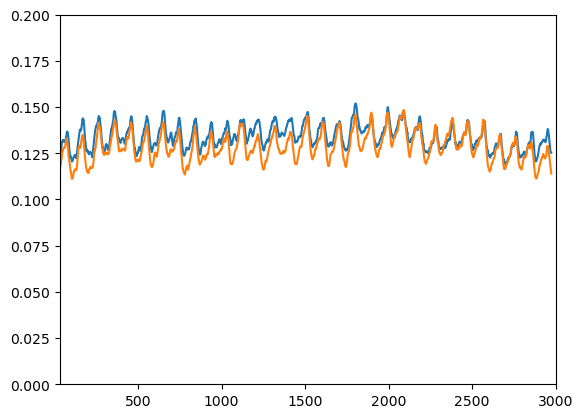

In [24]:
plt.plot(np.mean(Pr_pred_lins, axis=0))
plt.plot(np.mean(Pr_lins, axis=0))
plt.xlim(t_spinup, 3000)
plt.ylim(0, .2)

In [ ]:
numpyrize = lambda x: x.cpu().detach().numpy()

In [ ]:
Pr_combined = np.array([Pr_pred_lins, Pr_lins])
np.save('precip_ODE_predictions/20260518121043_Pr_combined_merged_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy', Pr_combined)

In [ ]:
Pr_combined = np.array([numpyrize(Pr_pred_resnonlin).flatten(), numpyrize(Pr_resnonlin).flatten()])
np.save('20260327125800_Pr_combined_residual_nonlinear_ODE_latent_dims=4_complexity=5p10_tp=20_global_oceanland.npy', Pr_combined)

In [11]:
Pr_combined = np.array([numpyrize(Pr_pred_nonlin).flatten(), numpyrize(Pr_nonlin).flatten()])
np.save('20260327125800_Pr_combined_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy', Pr_combined)